# Approach V5: 3. Three-Phase Feature Selection
**Project:** Honeywell Predictive Alerting Project - Tag: `03TIC_1023.PV` (Threshold: 21.0 °C)

This notebook implements the client's new three-phase feature selection pipeline:
1. **Phase 1**: Distance Correlation analysis vs. target and pairwise between all features to isolate 5 dominant independent features.
2. **Phase 2**: SHAP feature selection trained on the less dominant features.
3. **Phase 3**: Lasso L1 regularization on the combined feature pool to select exactly 12 final features.

In [1]:
# Adjust working directory to project root if run from inside approch_v5 folder
import os
import sys
if os.path.basename(os.getcwd()) == 'approch_v5':
    os.chdir('..')
    print("Changed working directory to project root:", os.getcwd())
sys.path.append(os.path.join(os.getcwd(), 'approch_v5'))

Changed working directory to project root: D:\Python-2025\Antigravity\honeywell


In [2]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from feature_selection import distance_correlation_phase_1, shap_phase_2, lasso_phase_3

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Data and Slice Train Split

In [3]:
df = pd.read_parquet("outputs/v5/candidate_features_pool.parquet")
print("Data loaded. Shape:", df.shape)
train_end = pd.to_datetime('2025-06-12 23:59:00')
train_df = df.loc[:train_end]
X_train = train_df.drop(columns=["03TIC_1023.PV"])
y_train = train_df["03TIC_1023.PV"]
print("Train split X shape:", X_train.shape, "y shape:", y_train.shape)

Data loaded. Shape: (2013380, 144)


Train split X shape: (1716314, 143) y shape: (1716314,)


## 2. Phase 1: Distance Correlation vs. Target & Pairwise

2026-07-16 23:21:17,427 - INFO - Executing Phase 1: Distance Correlation Analysis (vs. Target & Pairwise)...


C:\Users\Ajay_ML\miniconda3\Lib\site-packages\dcor\_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(int32, 1d, C), array(float64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(


2026-07-16 23:21:18,367 - INFO - Distance Correlation Phase 1 completed.


2026-07-16 23:21:18,369 - INFO - Selected Dominant Features (kept aside): ['03TIC_1023.PV_lag_1', '03PIC_1023.PV_roll_mean_60', '03TIC_1023.PV_roll_min_60', '03TIC_1023.PV_lag_60', '03TI_1081.PV_lag_1']


2026-07-16 23:21:18,369 - INFO - Remaining Less Dominant Features: 138


C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_27224\1629805241.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df.head(20), x="Distance_Correlation", y="Feature", palette="Blues_r")


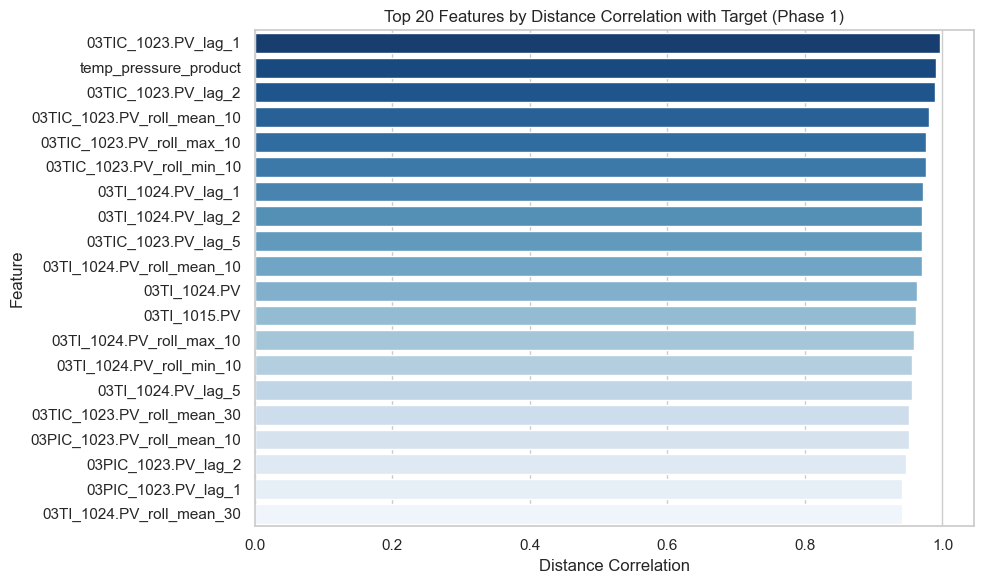

In [4]:
dominant_features, less_dominant_features, target_corrs = distance_correlation_phase_1(
    X_train, y_train, dominant_count=5, collinearity_threshold=0.90, sample_size=2000
)

# Plot top distance correlations with target
corr_df = pd.DataFrame(list(target_corrs.items()), columns=["Feature", "Distance_Correlation"]).sort_values(by="Distance_Correlation", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=corr_df.head(20), x="Distance_Correlation", y="Feature", palette="Blues_r")
plt.title("Top 20 Features by Distance Correlation with Target (Phase 1)")
plt.xlabel("Distance Correlation")
plt.ylabel("Feature")
plt.tight_layout()
os.makedirs("approch_v5", exist_ok=True)
plt.savefig("approch_v5/distance_correlation_rankings.png", dpi=300)
plt.show()

## 3. Phase 2: SHAP Feature Selection on Less Dominant Features

2026-07-16 23:21:19,244 - INFO - Executing Phase 2: SHAP Feature Importance Filtering on Less Dominant Features...


2026-07-16 23:22:01,290 - INFO - SHAP Phase 2 completed. Kept 58 less dominant features using threshold 0.0001.


C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_27224\885278490.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shap_df.head(20), x="Mean_Abs_SHAP", y="Feature", palette="Oranges_r")


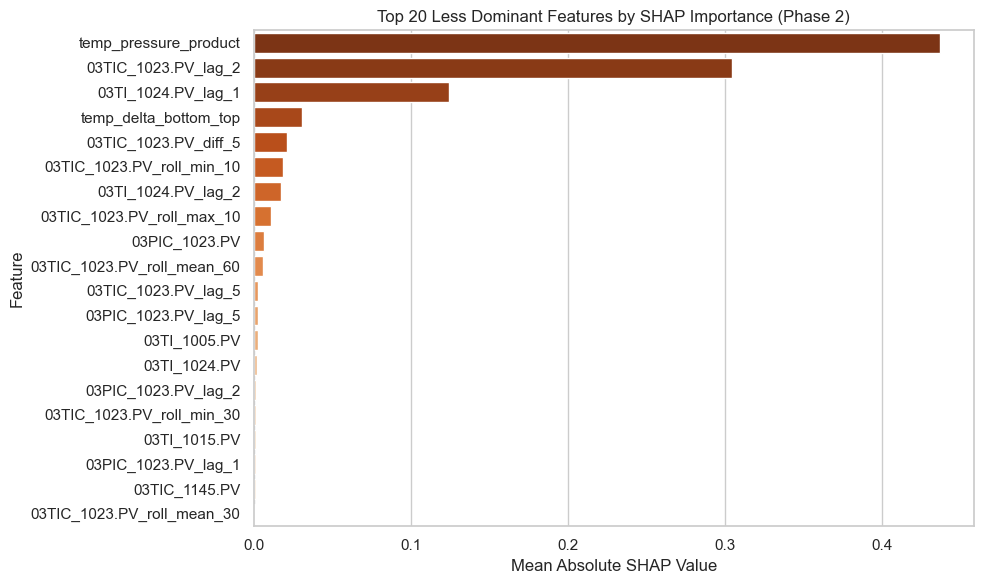

In [5]:
shap_selected, shap_df = shap_phase_2(X_train, y_train, less_dominant_features, threshold=1e-4, sample_size=5000)

# Plot top SHAP features
plt.figure(figsize=(10, 6))
sns.barplot(data=shap_df.head(20), x="Mean_Abs_SHAP", y="Feature", palette="Oranges_r")
plt.title("Top 20 Less Dominant Features by SHAP Importance (Phase 2)")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("approch_v5/shap_feature_importance.png", dpi=300)
plt.show()

## 4. Phase 3: Lasso L1 Regularization on Combined Feature Pool

2026-07-16 23:22:02,156 - INFO - Executing Phase 3: LassoCV L1 Regularization selection on combined features (Target: 12)...


Combined features pool size: 63


2026-07-16 23:27:42,611 - INFO - Phase 3 selection completed. Final 12 features selected.


C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_27224\3462318490.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=active_coefs, x="Coefficient", y="Feature", palette="coolwarm")


Final selected 12 features: ['03TIC_1023.PV_lag_5', '03TI_1024.PV', '03TIC_1023.PV_diff_5', '03TIC_1023.PV_lag_1', '03TI_1024.PV_lag_1', 'temp_delta_bottom_top', '03TIC_1023.PV_roll_max_10', '03TIC_1023.PV_roll_min_10', '03PIC_1023.PV', 'temp_pressure_product', '03TI_1015.PV', '03TIC_1023.PV_roll_mean_60']


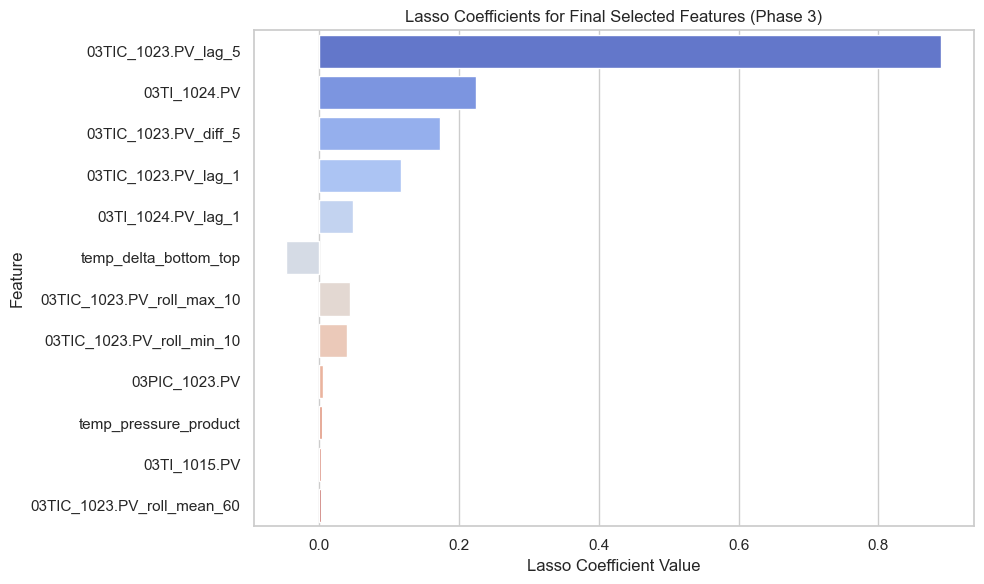

In [6]:
combined_features = dominant_features + shap_selected
print(f"Combined features pool size: {len(combined_features)}")

selected_features, coef_df = lasso_phase_3(X_train, y_train, combined_features, target_count=12)
print(f"Final selected 12 features: {selected_features}")

# Plot Lasso coefficients
active_coefs = coef_df[coef_df["Feature"].isin(selected_features)].copy()
plt.figure(figsize=(10, 6))
sns.barplot(data=active_coefs, x="Coefficient", y="Feature", palette="coolwarm")
plt.title("Lasso Coefficients for Final Selected Features (Phase 3)")
plt.xlabel("Lasso Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("approch_v5/lasso_coefficients.png", dpi=300)
plt.show()

## 5. Save Selected Features list

In [7]:
os.makedirs("models/v5", exist_ok=True)
with open("models/v5/selected_features_v5.pkl", "wb") as f:
    pickle.dump(selected_features, f)
print("Saved selected features to models/v5/selected_features_v5.pkl")

os.makedirs("approch_v5/models/v5", exist_ok=True)
with open("approch_v5/models/v5/selected_features_v5.pkl", "wb") as f:
    pickle.dump(selected_features, f)
print("Saved selected features to approch_v5/models/v5/selected_features_v5.pkl")

Saved selected features to models/v5/selected_features_v5.pkl
Saved selected features to approch_v5/models/v5/selected_features_v5.pkl
